# UnDirect multı layer network adding 

In [ ]:
conda deactivate # if you use conde firstable deactive conda 

In [3]:
import numpy as np
import pandas as pd
import math
import numpy as np
import pandas as pd
import math
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as img
#import snap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
#import seaborn as sn
import math
import warnings
from collections import deque
from heapq import heappop, heappush
from itertools import count
from networkx.algorithms.shortest_paths.weighted import _weight_function
from networkx.utils import py_random_state
from networkx.utils.decorators import not_implemented_for
from numpy.random import randint
from numpy.random import rand
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import networkx.algorithms.isomorphism as iso

----------------------------HIGHWAY LAYER


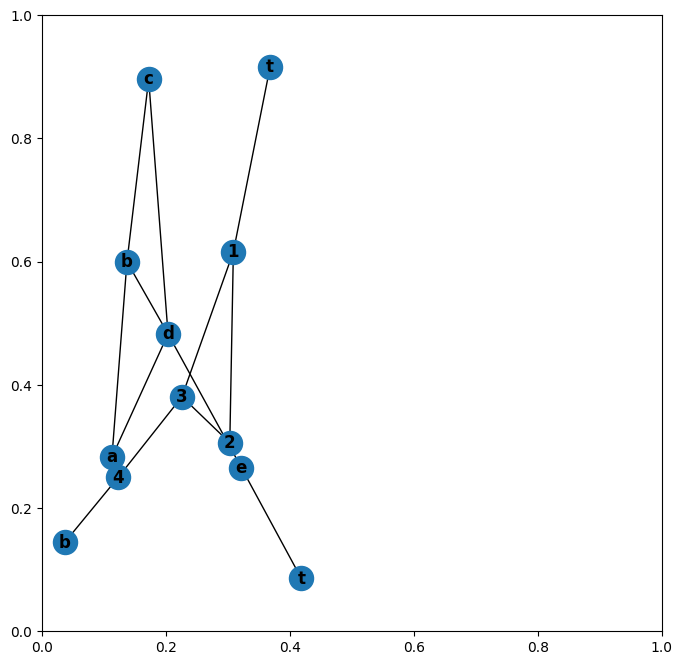

In [5]:
C=nx.Graph()
C_copy=nx.Graph()
E=nx.Graph()
F=nx.Graph()
C.add_weighted_edges_from([("t", "e", 1.0), ("e", "d", 1.0),("d", "a", 1.0), ("d", "c", 1.0),("a", "b", 1.0),("c", "b", 1.0), ("b","d",2.1)]) #
E.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0),(4, "b", 1.0),(1, "t", 1.0)])
C_copy.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0)])
F.add_weighted_edges_from([(1,2, 1.0), (2, 3, 1.0),(3, 1, 1.0), (3, 4, 1.0),(4, "b", 1.0),(1, "t", 1.0)])
plt.subplots(figsize=(8,8))
plt.subplot(121)
#nx.draw(C, with_labels=True, font_weight='bold')


nx.draw(E, with_labels=True, font_weight='bold')



print("----------------------------HIGHWAY LAYER")
nx.draw(C, with_labels=True, font_weight='bold')

-----------------METRO LAYER


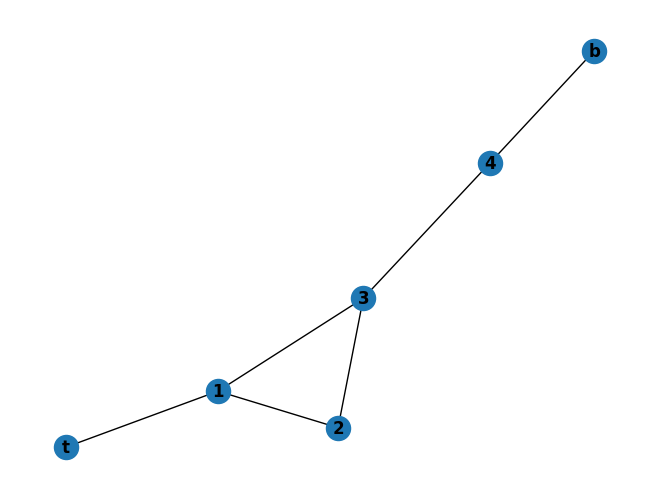

In [9]:
print( "-----------------METRO LAYER")

nx.draw(E, with_labels=True, font_weight='bold')

 ------------------------MULTI LAYER METRO AND HIGHWAY 


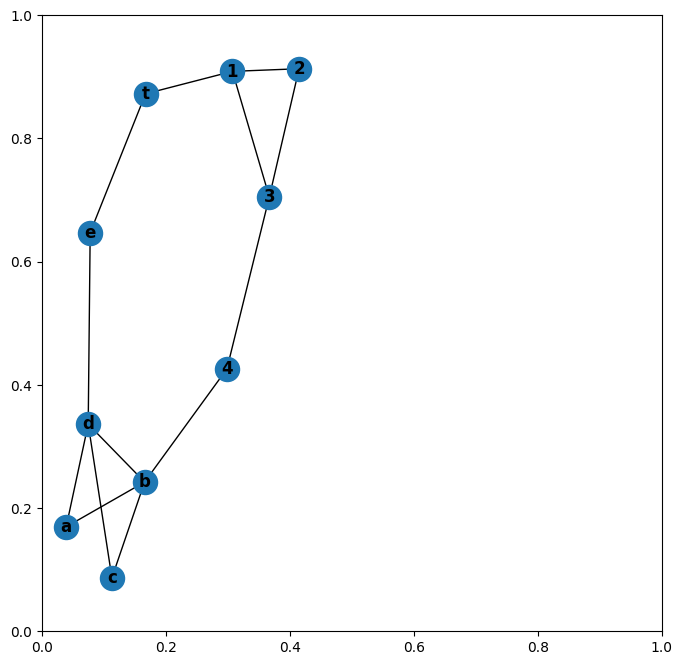

In [11]:
F.add_edges_from(C.edges)
plt.subplots(figsize=(8,8))
plt.subplot(121)
print(" ------------------------MULTI LAYER METRO AND HIGHWAY ")
nx.draw(F, with_labels=True, font_weight='bold')

In [14]:
def decode(bounds, n_bits, bitstring, budget,C_copy):  
    decoded = list()
    largest = 2**n_bits  
    for i in range(len(bounds)):   
        start, end = i * n_bits, (i * n_bits)+n_bits 
        substring =  bitstring[start:end] 
        chars = ''.join([str(s) for s in substring])    
        integer = int(chars, 2)
        value = bounds[i][0] + (integer/largest) * (bounds[i][1] - bounds[i][0]) 
        decoded.append((list(C_copy.edges)[round(value)-1][0],list(C_copy.edges)[round(value)-1][1]))
    return(decoded)

In [17]:
# tournament selection
def selection(pop, scores, k=3):
    # first random selection
    selection_ix = randint(len(pop))
    for ix in randint(0, len(pop), k-1):
        # check if better (e.g. perform a tournament)
        if scores[ix] < scores[selection_ix]:
            selection_ix = ix
    return pop[selection_ix]


In [20]:
# crossover two parents to create two children
def crossover(p1, p2, r_cross):
# children are copies of parents by default
    c1, c2 = p1.copy(), p2.copy()
    # check for recombination
    if rand() < r_cross:
        # select crossover point that is not on the end of the string
        pt = randint(1, len(p1)-2)
        # perform crossover
        c1 = p1[:pt] + p2[pt:]
        c2 = p2[:pt] + p1[pt:]
    return [c1, c2]

In [23]:
# mutation operator
def mutation(bitstring, r_mut): # mutation(c, r_mut)
    for i in range(len(bitstring)):
        # check for a mutation
        if rand() < r_mut:
            # flip the bit
            bitstring[i] = 1 - bitstring[i]

# If you calculate  all layer optimizastion , use below objective 

In [27]:
def objective(x,E,C,C_copy,alfa):  
    if x !=list(set(x)):
        return(15)
    

    
    else:
        MLB={}
        B=[]
        for b in range(len(E.edges)):
            B.append((list(E.edges.data())[b][0],list(E.edges.data(b))[b][1],list(E.edges.data())[b][2]["weight"]))



        R=nx.Graph()
        P=nx.Graph()
        R.add_weighted_edges_from(B)
        P.add_weighted_edges_from(B)
        R.add_edges_from(C.edges)
        R.remove_edges_from(x)
        P.remove_edges_from(x)

        katman2=nx.edge_betweenness_centrality(P,weight="weight")
        sources= list(P.nodes())
        targets= list(C.nodes())
        katman1=nx.edge_betweenness_centrality(C,weight="weight")
        katman1_2=nx.edge_betweenness_centrality_subset(R, sources, targets, normalized=False, weight="weight") #NODE İÇİN ,
        liste1=list(katman1.keys())
        liste2=list(katman2.keys())
        liste=list(katman1_2.keys())

        for i in list(R.nodes): 
            for j in list(R.nodes): 
                if (i,j)  in liste: 
                    if (i,j) in liste1:
                        MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman1[(i,j)])*alfa)
                    if (j,i) in liste1:  
                        MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman1[(j,i)])*alfa)
                    if (i,j) in liste2:  
                        MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman2[(i,j)])*alfa)
                    if (j,i) in liste2:
                        MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman2[(j,i)])*alfa)     
    return(np.std(list(MLB.values())))

In [31]:
# genetic algorithm
def genetic_algorithm(objective, bounds, n_bits, n_iter, n_pop, r_cross, r_mut,budget,E,C,C_copy,alfa):
    # initial population of random bitstring
    pop = [randint(0, 2, n_bits*len(bounds)).tolist() for _ in range(n_pop)] 
    # keep track of best solution
    best, best_eval = 0, objective(decode(bounds, n_bits, pop[0],budget,C_copy),E,C,C_copy,alfa) 
    # enumerate generations
    for gen in range(n_iter): 
        # decode population
        decoded = [decode(bounds, n_bits, p, budget,C_copy) for p in pop] 
        # evaluate all candidates in the population
        scores = [objective(x,E,C,C_copy,alfa) for x in decoded] 
      
        for i in range(n_pop): 
            if scores[i] < best_eval: 
                best, best_eval = pop[i], scores[i] 
                print(">%d, new best f(%s) = %f" % (gen,  decoded[i], scores[i]))
        # select parents
        selected = [selection(pop, scores) for _ in range(n_pop)] 
       
        children = list() 
        for i in range(0, n_pop, 2): 
          
            p1, p2 = selected[i], selected[i+1]
            # crossover and mutation
            for c in crossover(p1, p2, r_cross):  
                # mutation
                mutation(c, r_mut)
                # store for next generation
                children.append(c) 
        # replace population
        pop = children 
      
    return [best, best_eval]

In [34]:
# define range for input
alfa=0.8
budget=2
bounds = [[0.0, 4.0]]*budget 
# define the total iterations
n_iter = 10 #

n_bits = 8 
# define the population size
n_pop = 10
# crossover rate
r_cross = 0.5
# mutation rate
r_mut = 1.0 / (float(n_bits) * len(bounds))
# perform the genetic algorithm search
best, score = genetic_algorithm(objective, bounds, n_bits, n_iter, n_pop, r_cross, r_mut,budget,E,C,C_copy,alfa)
print('Done!')
print( best,score)
decoded = decode(bounds, n_bits, best, budget,C_copy)
print('f(%s) = %f' % (decoded, score))

>0, new best f([(1, 2), (1, 3)]) = 0.588187
>1, new best f([(2, 3), (1, 2)]) = 0.340704
Done!
[1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1] 0.34070364179667484
f([(2, 3), (1, 2)]) = 0.340704


In [36]:
decoded

[(2, 3), (1, 2)]

# Output  for all layer 

# If you calculate  only upper layer optimizastion , use below objective

In [44]:
#x = [(decoded[i], decoded[i+1]) for i in range(0, len(decoded), 2)]
x= decoded     

MLB={}
B=[]
for b in range(len(E.edges)):
    B.append((list(E.edges.data())[b][0],list(E.edges.data(b))[b][1],list(E.edges.data())[b][2]["weight"]))



R=nx.Graph()
P=nx.Graph()
R.add_weighted_edges_from(B)
P.add_weighted_edges_from(B)
R.add_edges_from(C.edges)
R.remove_edges_from(x)
P.remove_edges_from(x)

katman2=nx.edge_betweenness_centrality(P,weight="weight")
sources= list(P.nodes())
targets= list(C.nodes())
katman1=nx.edge_betweenness_centrality(C,weight="weight")
katman1_2=nx.edge_betweenness_centrality_subset(R, sources, targets, normalized=False, weight="weight") #NODE İÇİN ,
liste1=list(katman1.keys())
liste2=list(katman2.keys())
liste=list(katman1_2.keys())

for i in list(R.nodes): # birleştirilmiş network nokta listesi
    for j in list(R.nodes): 
        if (i,j)  in liste: # eğer i j kenarı birleşik katman listesinde var ise 
            if (i,j) in liste1: # kenar ilk katmanda var sa inter ve intra oranında çarp
                MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman1[(i,j)])*alfa)
            if (j,i) in liste1:  # kenarın tersi ilk katmanda var ise inter ve intra oranında çarp
                MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman1[(j,i)])*alfa)
            if (i,j) in liste2: # i,j  kenar ikinci katmanda var ise  ikinci katmanla birleştirlmiş katmanı çarp 
                MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman2[(i,j)])*alfa)
            if (j,i) in liste2:#  j,i  kenar ikinci katmanda var ise  ikinci katmanla birleştirlmiş katmanı çarp 
                MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman2[(j,i)])*alfa)     
print(np.std(list(MLB.values())))

0.34070364179667484


In [46]:
MLB

{(1, 3): 0.82,
 (1, 't'): 0.9133333333333332,
 (3, 4): 1.02,
 ('t', 'e'): 1.2666666666666664,
 (4, 'b'): 1.313333333333333,
 ('b', 'd'): 0.6999999999999998,
 ('b', 'a'): 0.51,
 ('b', 'c'): 0.51,
 ('e', 'd'): 1.3266666666666664,
 ('d', 'a'): 0.41666666666666663,
 ('d', 'c'): 0.41666666666666663}

In [48]:
list(MLB.values())

[0.82,
 0.9133333333333332,
 1.02,
 1.2666666666666664,
 1.313333333333333,
 0.6999999999999998,
 0.51,
 0.51,
 1.3266666666666664,
 0.41666666666666663,
 0.41666666666666663]

In [50]:
#New standart deviation for 1 layer highway 
np.std(list(MLB.values()))

np.float64(0.34070364179667484)

# T0 time all layer sd   0.495

# Output for upper layer  

In [56]:
def objective(x,E,C,C_copy,alfa):  
    if x !=list(set(x)):
        return(15)
    
    else:
        MLB={}
        B=[]
        for b in range(len(E.edges)):
            B.append((list(E.edges.data())[b][0],list(E.edges.data(b))[b][1],list(E.edges.data())[b][2]["weight"]))



        R=nx.Graph()
        P=nx.Graph()
        R.add_weighted_edges_from(B)
        P.add_weighted_edges_from(B)
        R.add_edges_from(C.edges)
        R.remove_edges_from(x)
        P.remove_edges_from(x)

        katman2=nx.edge_betweenness_centrality(P,weight="weight")
        sources= list(P.nodes())
        targets= list(C.nodes())
        katman1=nx.edge_betweenness_centrality(C,weight="weight")
        katman1_2=nx.edge_betweenness_centrality_subset(R, sources, targets, normalized=False, weight="weight") #NODE İÇİN ,
        liste1=list(katman1.keys())
        liste2=list(katman2.keys())
        liste=list(katman1_2.keys())

        for i in list(R.nodes): # birleştirilmiş network nokta listesi
            for j in list(R.nodes): 
                if (i,j)  in liste: # eğer i j kenarı birleşik katman listesinde var ise 
                    if (i,j) in liste1: # kenar ilk katmanda var sa inter ve intra oranında çarp
                        MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman1[(i,j)])*alfa)
                    if (j,i) in liste1:  # kenarın tersi ilk katmanda var ise inter ve intra oranında çarp
                        MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman1[(j,i)])*alfa)
                    if (i,j) in liste2: # i,j  kenar ikinci katmanda var ise  ikinci katmanla birleştirlmiş katmanı çarp 
                        MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman2[(i,j)])*alfa)
                    if (j,i) in liste2:#  j,i  kenar ikinci katmanda var ise  ikinci katmanla birleştirlmiş katmanı çarp 
                        MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman2[(j,i)])*alfa)  
    H=[]
    for h in list(C.edges):
        if h in list(MLB.keys()):
            H.append(MLB[h])
        elif (h[1],h[0]) in list(MLB.keys()):
            H.append(MLB[(h[1],h[0])])
            
            
            
            
    return(np.std(H))


In [58]:
# define range for input
alfa=0.8
budget=2
bounds = [[0.0, 4.0]]*budget #bu uazay aralığında 
# define the total iterations
n_iter = 10 #
# bits per variable
n_bits = 8 # 16 lık barkot şeklinde 
# define the population size
n_pop = 10
# crossover rate
r_cross = 0.5
# mutation rate
r_mut = 1.0 / (float(n_bits) * len(bounds))
# perform the genetic algorithm search
best, score = genetic_algorithm(objective, bounds, n_bits, n_iter, n_pop, r_cross, r_mut,budget,E,C,C_copy,alfa)
print('Done!')
print( best,score)
decoded = decode(bounds, n_bits, best, budget,C_copy)
print('f(%s) = %f' % (decoded, score))

>1, new best f([(2, 3), (1, 3)]) = 0.716993
>2, new best f([(1, 2), (1, 3)]) = 0.610796
Done!
[0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0] 0.6107962907905854
f([(1, 2), (1, 3)]) = 0.610796


In [60]:
decoded 

[(1, 2), (1, 3)]

In [64]:
#x = [(decoded[i], decoded[i+1]) for i in range(0, len(decoded), 2)] # if buget more than 1 
x= decoded # if budget 1 
MLB={}
B=[]
for b in range(len(E.edges)):
    B.append((list(E.edges.data())[b][0],list(E.edges.data(b))[b][1],list(E.edges.data())[b][2]["weight"]))



R=nx.Graph()
P=nx.Graph()
R.add_weighted_edges_from(B)
P.add_weighted_edges_from(B)
R.add_edges_from(C.edges)
R.remove_edges_from(x)
P.remove_edges_from(x)

katman2=nx.edge_betweenness_centrality(P,weight="weight")
sources= list(P.nodes())
targets= list(C.nodes())
katman1=nx.edge_betweenness_centrality(C,weight="weight")
katman1_2=nx.edge_betweenness_centrality_subset(R, sources, targets, normalized=False, weight="weight") #NODE İÇİN ,
liste1=list(katman1.keys())
liste2=list(katman2.keys())
liste=list(katman1_2.keys())

for i in list(R.nodes): # birleştirilmiş network nokta listesi
    for j in list(R.nodes): 
        if (i,j)  in liste: # eğer i j kenarı birleşik katman listesinde var ise 
            if (i,j) in liste1: # kenar ilk katmanda var sa inter ve intra oranında çarp
                MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman1[(i,j)])*alfa)
            if (j,i) in liste1:  # kenarın tersi ilk katmanda var ise inter ve intra oranında çarp
                MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman1[(j,i)])*alfa)
            if (i,j) in liste2: # i,j  kenar ikinci katmanda var ise  ikinci katmanla birleştirlmiş katmanı çarp 
                MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman2[(i,j)])*alfa)
            if (j,i) in liste2:#  j,i  kenar ikinci katmanda var ise  ikinci katmanla birleştirlmiş katmanı çarp 
                MLB[(i,j)]=(katman1_2[(i,j)]*(1-alfa)+(katman2[(j,i)])*alfa)  
H=[]
for h in list(C.edges):
    if h in list(MLB.keys()):
        H.append(MLB[h])
    elif (h[1],h[0]) in list(MLB.keys()):
        H.append(MLB[(h[1],h[0])])
        
        
        
        
print(np.std(H))


0.6107962907905854


In [66]:
MLB

{(1, 't'): 0.6533333333333332,
 (2, 3): 0.7599999999999999,
 (3, 4): 1.413333333333333,
 ('t', 'e'): 1.6666666666666663,
 (4, 'b'): 1.9599999999999995,
 ('b', 'd'): 1.3999999999999997,
 ('b', 'a'): 0.5599999999999999,
 ('b', 'c'): 0.5599999999999999,
 ('e', 'd'): 2.0266666666666664,
 ('d', 'a'): 0.4666666666666666,
 ('d', 'c'): 0.4666666666666666}

In [68]:
list(MLB.values()) # All layer 

[0.6533333333333332,
 0.7599999999999999,
 1.413333333333333,
 1.6666666666666663,
 1.9599999999999995,
 1.3999999999999997,
 0.5599999999999999,
 0.5599999999999999,
 2.0266666666666664,
 0.4666666666666666,
 0.4666666666666666]

In [70]:
H # only upper layer 

[1.6666666666666663,
 2.0266666666666664,
 0.4666666666666666,
 0.4666666666666666,
 1.3999999999999997,
 0.5599999999999999,
 0.5599999999999999]

In [72]:
#New standart deviation for 1 layer highway t1 time 
print(np.std(H))

0.6107962907905854


# T0 time Upper layer sd 0.393